1. 런타임유형 GPU로 변경 후 GPU사용 가능여부 확인



In [1]:
import tensorflow as tf
from tensorflow.python.client import device_lib

print("🚀 텐서플로우 버전:", tf.__version__)
print(device_lib.list_local_devices())

2026-05-05 23:51:33.450708: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 23:51:33.753132: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-05 23:51:33.753209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-05 23:51:33.809844: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-05 23:51:33.916719: I tensorflow/core/platform/cpu_feature_guar

🚀 텐서플로우 버전: 2.15.0
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 1608149521792891718
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14006878208
locality {
  bus_id: 1
  links {
  }
}
incarnation: 10372304508320635970
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0"
xla_global_id: 416903419
]


2026-05-05 23:51:36.108811: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 23:51:36.308590: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 23:51:36.308651: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 23:51:36.308656: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-05-05 23:51:36.422499: I external/lo

4.라이브러리 불러오기

In [1]:
!pip install imgaug
!pip install "numpy<2.0"

ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [2]:
import os
import random
import fnmatch
import datetime
import pickle

# data processing
import numpy as np
np.set_printoptions(formatter={'float_kind':lambda x: "%.4f" % x})

import pandas as pd
pd.set_option('display.width', 300)
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_colwidth', 200)

# tensorflow
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.models import Sequential  # V2 is tensorflow.keras.xxxx, V1 is keras.xxx
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

print( f'tf.__version__: {tf.__version__}' )

# sklearn
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# imaging
import cv2
from imgaug import augmenters as img_aug
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image

tf.__version__: 2.15.0


5.데이터 불러오기

In [3]:
import os
print(len(os.listdir('/home/swjin/project/video')))

14466


In [4]:
import os
import fnmatch
import pandas as pd
import numpy as np
import cv2
from sklearn.utils import shuffle
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm
import gc

# ==========================================
# 1. 파일명 파싱 (Command 포함) 및 DataFrame 생성
# ==========================================
data_dir = '/home/swjin/project/video'
file_list = os.listdir(data_dir)

image_paths, commands, left_pwms, right_pwms = [], [], [], []
pattern = "*.jpg"

for filename in file_list:
    if fnmatch.fnmatch(filename, pattern):
        image_paths.append(os.path.join(data_dir, filename))
        parts = filename.replace('.jpg', '').split('_')

        commands.append(int(parts[2][1:]))
        left_pwms.append(int(parts[3][1:]))
        right_pwms.append(int(parts[4][1:]))

df = pd.DataFrame({'ImagePath': image_paths, 'Command': commands, 'Left': left_pwms, 'Right': right_pwms})

# 정지 상태(Speed == 0) 데이터 제거 및 조향각(Steering) 계산
df['Speed'] = df[['Left', 'Right']].abs().max(axis=1)
df = df[df['Speed'] != 0].copy()
df['Steering'] = (df['Left'] - df['Right']) / (2 * df['Speed'])
df = df[df['Steering'].abs() <= 1.0].copy()

# ==========================================
# 1.5 [수정] C0 스마트 언더샘플링 (비율 보장형)
# ==========================================
print(f"⚖️ 밸런싱 전 데이터 개수: {len(df)}장")

target_count = df[df['Command'] != 0]['Command'].value_counts().max()

df_c0 = df[df['Command'] == 0]
df_others = df[df['Command'] != 0]

# 조향각 임계값 분리
steering_threshold = 0.15 
df_c0_straight = df_c0[df_c0['Steering'].abs() <= steering_threshold]
df_c0_curve = df_c0[df_c0['Steering'].abs() > steering_threshold]

print(f"🔍 C0 분석: 곡선 데이터 {len(df_c0_curve)}장 / 직진 데이터 {len(df_c0_straight)}장")

# 💡 [핵심 수정] 무조건 곡선 60%, 직진 40% 비율로 섞어서 추출합니다.
target_curve = int(target_count * 0.6)

# 데이터가 모자랄 경우를 대비한 안전 장치
n_curve = min(target_curve, len(df_c0_curve))
n_straight = min(target_count - n_curve, len(df_c0_straight))

# 만약 직진이 모자라서 타겟을 못 채웠다면, 곡선에서 다시 보충
if n_curve + n_straight < target_count:
    n_curve = min(target_count - n_straight, len(df_c0_curve))

df_c0_curve_sampled = df_c0_curve.sample(n=n_curve, random_state=42)
df_c0_straight_sampled = df_c0_straight.sample(n=n_straight, random_state=42)

# 직진과 곡선을 찰진 비율로 병합
df_c0_sampled = pd.concat([df_c0_curve_sampled, df_c0_straight_sampled])
df = pd.concat([df_c0_sampled, df_others]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"⚖️ 밸런싱 후 데이터 개수: {len(df)}장 (C0 황금 비율 샘플링 완료!)")

# ==========================================
# 2. [메모리 최적화] 이미지 처리 & 모든 커맨드 좌우 반전 증강
# ==========================================
num_original = len(df)
num_augmented = len(df) # 모든 데이터를 반전
total_samples = num_original + num_augmented

print(f"\n📦 예상되는 총 데이터 개수: {total_samples}장 (전체 2배 증강)")

X_images = np.zeros((total_samples, 96, 320, 3), dtype=np.float32)
X_commands_raw = np.zeros(total_samples, dtype=np.int8) 
y_steering = np.zeros(total_samples, dtype=np.float32)

broken_files = 0
current_idx = 0 

for index, row in tqdm(df.iterrows(), total=num_original, desc="Processing Images"):
    img_bgr = cv2.imread(row['ImagePath'])

    if img_bgr is None:
        broken_files += 1
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_yuv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YUV)
    img_normalized = np.float32(img_yuv) / 255.0

    cmd = row['Command']
    steer = row['Steering']

    # 원본 데이터 삽입
    X_images[current_idx] = img_normalized
    X_commands_raw[current_idx] = cmd
    y_steering[current_idx] = steer
    current_idx += 1

    # 좌우 반전 데이터 삽입
    X_images[current_idx] = cv2.flip(img_normalized, 1)
    
    if cmd == 1:
        X_commands_raw[current_idx] = 2 
    elif cmd == 2:
        X_commands_raw[current_idx] = 1 
    else:
        X_commands_raw[current_idx] = cmd 
        
    y_steering[current_idx] = -steer 
    current_idx += 1

X_images = X_images[:current_idx]
X_commands_raw = X_commands_raw[:current_idx]
y_steering = y_steering[:current_idx]

print(f"\n❌ 깨져서 버려진 파일 개수: {broken_files}장")

# 모든 처리가 끝난 후에 df를 삭제하여 RAM 확보!
del df
gc.collect()

# ==========================================
# 3. 배열 변환 및 원핫 인코딩
# ==========================================
X_commands_onehot = to_categorical(X_commands_raw, num_classes=4)

# ==========================================
# 4. 시계열 단절 (동기화 셔플)
# ==========================================
X_images, X_commands_onehot, X_commands_raw, y_steering = shuffle(
    X_images, X_commands_onehot, X_commands_raw, y_steering, random_state=42
)

print("\n✅ AI 학습용 다중 입력 데이터 준비 완벽하게 완료!")

⚖️ 밸런싱 전 데이터 개수: 14466장
🔍 C0 분석: 곡선 데이터 4276장 / 직진 데이터 4380장
⚖️ 밸런싱 후 데이터 개수: 8070장 (C0 황금 비율 샘플링 완료!)

📦 예상되는 총 데이터 개수: 16140장 (전체 2배 증강)


Processing Images: 100%|██████████| 8070/8070 [00:05<00:00, 1390.28it/s]



❌ 깨져서 버려진 파일 개수: 51장

✅ AI 학습용 다중 입력 데이터 준비 완벽하게 완료!


6.조향각의 분포를 확인



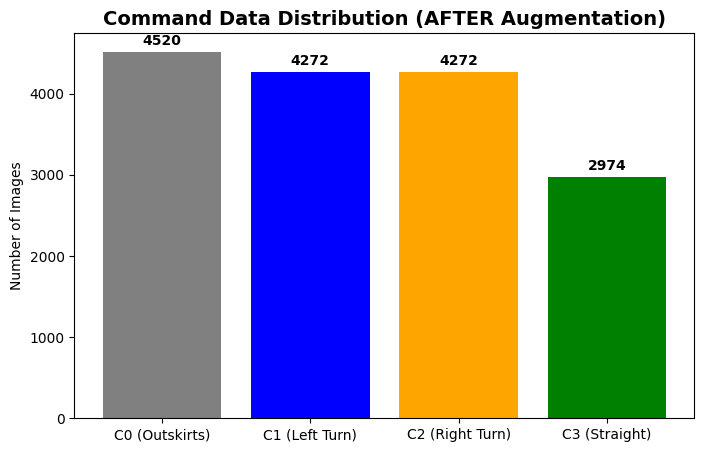

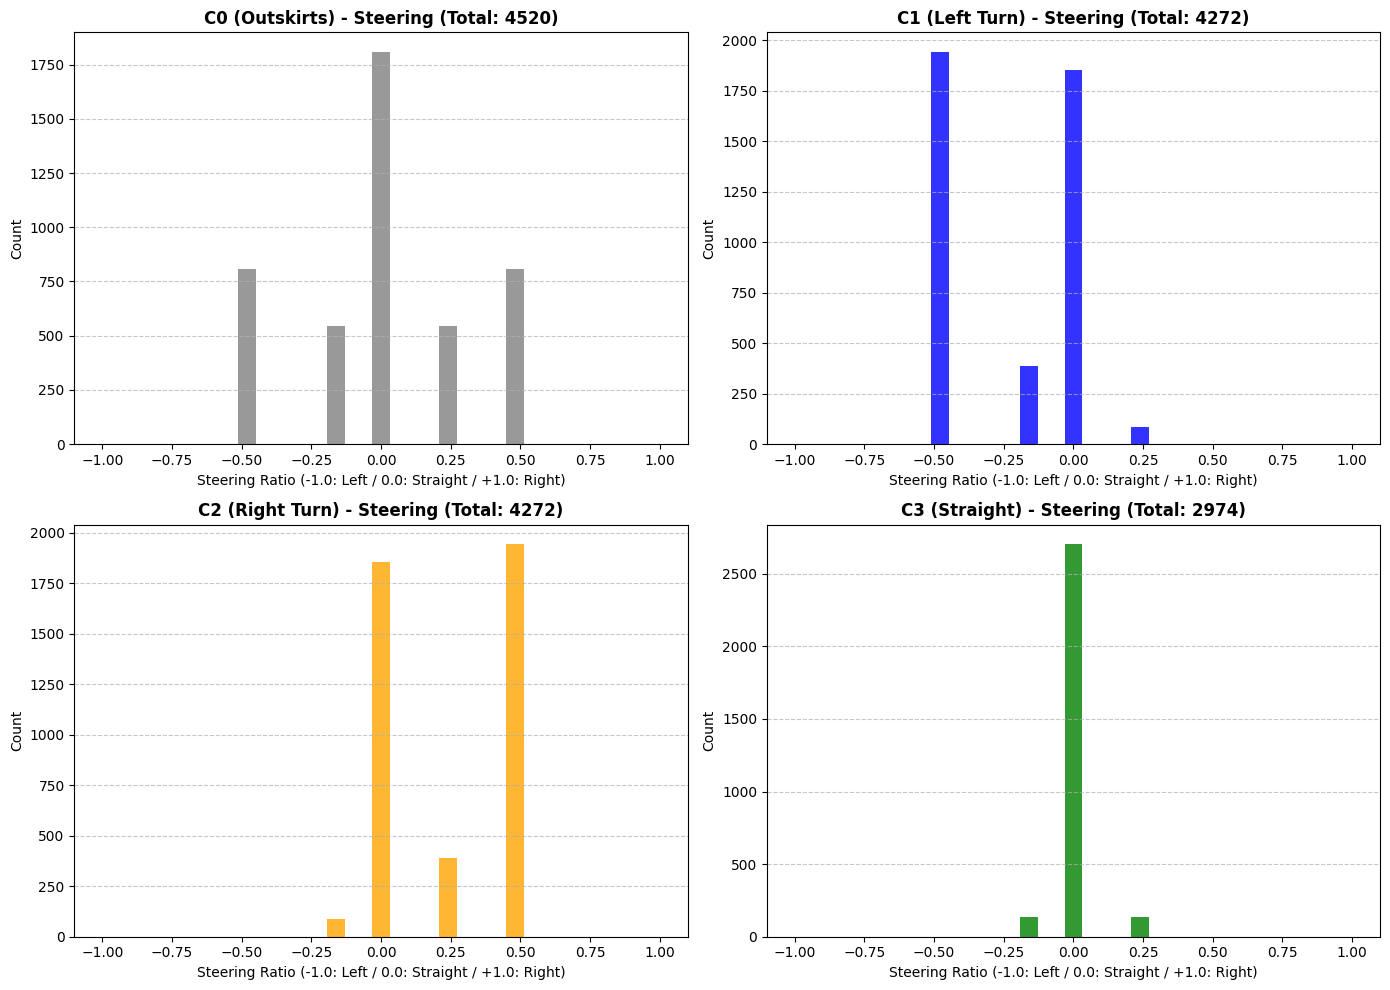

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 증강 후 커맨드(C0~C3) 데이터 개수 분포 확인
# ==========================================
# df['Command'].value_counts() 대신 Numpy의 unique 함수 사용
unique_cmds, counts = np.unique(X_commands_raw, return_counts=True)
colors = ['gray', 'blue', 'orange', 'green']
labels = ['C0 (Outskirts)', 'C1 (Left Turn)', 'C2 (Right Turn)', 'C3 (Straight)']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=colors)
plt.title("Command Data Distribution (AFTER Augmentation)", fontsize=14, fontweight='bold')
plt.ylabel("Number of Images")

# 막대 위에 정확한 개수 적어주기
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontweight='bold')

plt.show()

# ==========================================
# 2. 증강 후 커맨드별 조향각(Steering) 세부 분포 확인
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i in range(4):
    # 💡 핵심: df가 아니라 numpy 배열에서 해당 커맨드(i)의 조향값만 쏙 뽑아옵니다.
    subset_steering = y_steering[X_commands_raw == i]

    # 히스토그램 그리기
    axes[i].hist(subset_steering, bins=25, range=(-1.0, 1.0), color=colors[i], rwidth=0.8, alpha=0.8)

    # 그래프 꾸미기 (제목에 총 데이터 개수 표시)
    axes[i].set_title(f"{labels[i]} - Steering (Total: {len(subset_steering)})", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Steering Ratio (-1.0: Left / 0.0: Straight / +1.0: Right)")
    axes[i].set_ylabel("Count")
    axes[i].set_xlim(-1.1, 1.1)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

7. 학습데이터와 검증데이터를 분리

✅ 다중 입력(Multi-Input) 데이터를 8:2로 안전하게 쪼갭니다!
✅ Training data: 12830장
✅ Validation data: 3208장


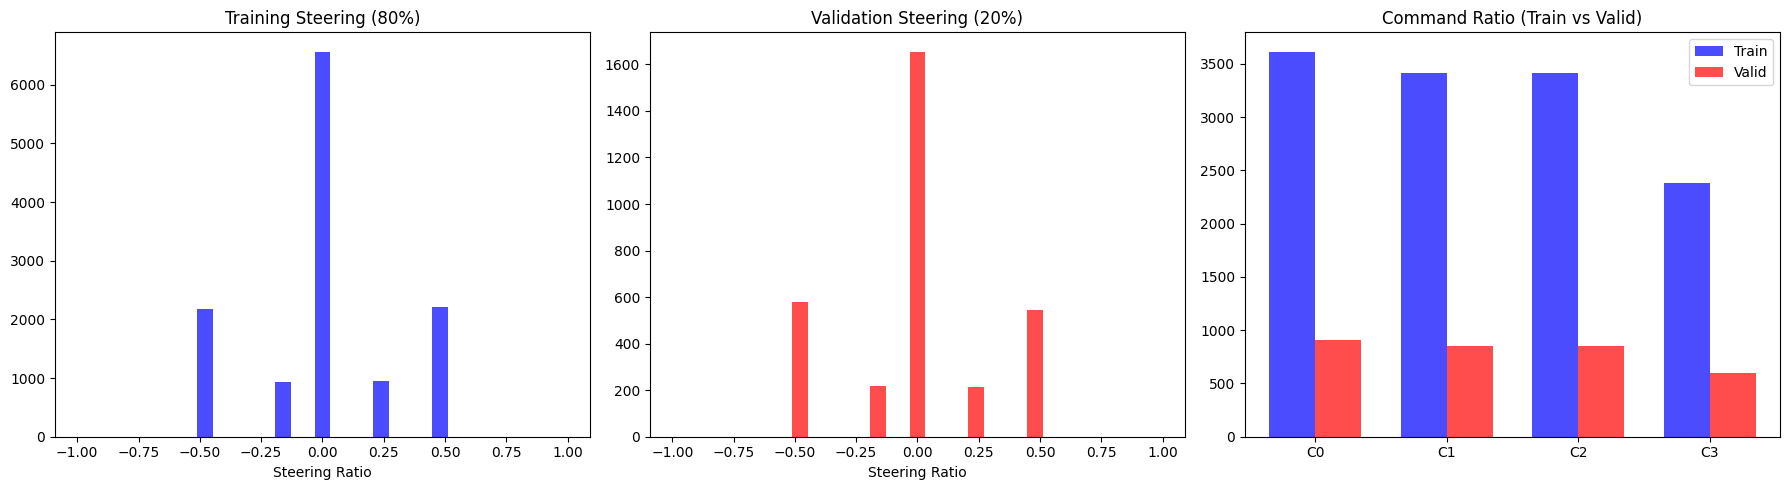

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("✅ 다중 입력(Multi-Input) 데이터를 8:2로 안전하게 쪼갭니다!")

# 1. 💡 이미지, 원핫 커맨드, 원본 커맨드, 조향값을 '동시에' 8:2로 분할합니다.
# stratify=X_commands_raw 옵션으로 모든 커맨드의 8:2 비율을 강제로 동일하게 맞춥니다.
X_train_img, X_valid_img, X_train_cmd, X_valid_cmd, y_train, y_valid, cmd_raw_train, cmd_raw_valid = train_test_split(
    X_images,              # 첫 번째 입력: 이미지
    X_commands_onehot,     # 두 번째 입력: 원핫 인코딩된 커맨드
    y_steering,            # 출력: 조향값
    X_commands_raw,        # 비율 맞추기 및 확인용 원본 커맨드
    test_size=0.2,
    random_state=42,
    stratify=X_commands_raw # <--- [핵심] 클래스 비율 붕괴 방지!
)

print(f"✅ Training data: {len(X_train_img)}장")
print(f"✅ Validation data: {len(X_valid_img)}장")

# ==========================================
# 2. 분포 그래프 확인 (조향값 & 커맨드 비율)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 훈련 데이터 조향각 분포
axes[0].hist(y_train, bins=25, range=(-1.0, 1.0), rwidth=0.8, color='blue', alpha=0.7)
axes[0].set_title(f'Training Steering (80%)')
axes[0].set_xlabel('Steering Ratio')

# (2) 검증 데이터 조향각 분포
axes[1].hist(y_valid, bins=25, range=(-1.0, 1.0), rwidth=0.8, color='red', alpha=0.7)
axes[1].set_title(f'Validation Steering (20%)')
axes[1].set_xlabel('Steering Ratio')

# (3) 💡 훈련/검증 데이터의 커맨드 비율이 잘 유지되었는지 확인 (Stratify 검증)
cmd_labels = ['C0', 'C1', 'C2', 'C3']
train_counts = np.bincount(cmd_raw_train, minlength=4)
valid_counts = np.bincount(cmd_raw_valid, minlength=4)

x = np.arange(len(cmd_labels))
width = 0.35

axes[2].bar(x - width/2, train_counts, width, label='Train', color='blue', alpha=0.7)
axes[2].bar(x + width/2, valid_counts, width, label='Valid', color='red', alpha=0.7)
axes[2].set_title('Command Ratio (Train vs Valid)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(cmd_labels)
axes[2].legend()

plt.tight_layout()
plt.show()

8. 이미지 읽어오기 및 정규화함수

In [8]:
import os
# 첫 번째 사진 경로가 실제로 존재하는지 True / False 로 확인
image_index = 0
print(image_paths[image_index])
print(os.path.exists(image_paths[image_index]))

/home/swjin/project/video/video_08719_C3_L+050_R+050.jpg
True


In [9]:
path = image_paths[image_index]
print(f"파일 크기: {os.path.getsize(path)} bytes")

파일 크기: 3163 bytes


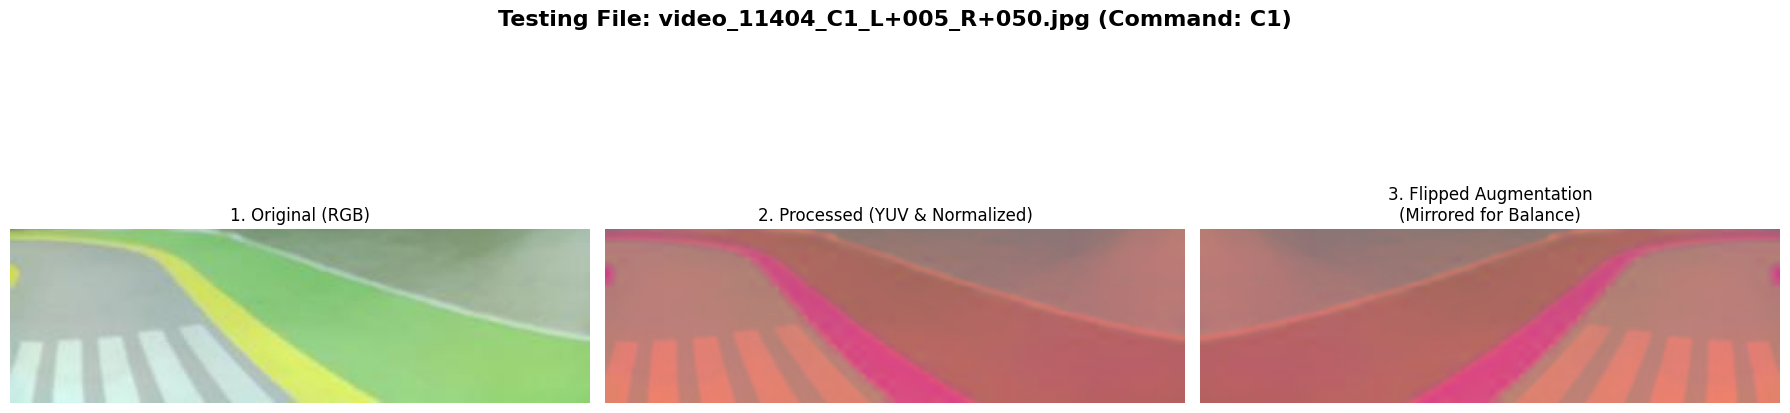

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

def my_imread(image_path):
    # 1. cv2.imread는 기본적으로 이미지를 BGR 형태로 불러옵니다.
    image_bgr = cv2.imread(image_path)

    # 2. 학습 코드와 동일하게 RGB로 변환합니다.
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return image_rgb

def img_preprocess(image_rgb):
    # 💡 RGB를 YUV 색상 공간으로 변환!
    image_yuv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2YUV)

    # 정규화 (0~255 -> 0.0~1.0)
    image_normalized = np.float32(image_yuv) / 255.0
    return image_normalized

# ==========================================
# 테스트할 이미지 파일 랜덤으로 하나 가져오기
# ==========================================
data_dir = '/home/swjin/project/video'
all_files = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]
random_file = random.choice(all_files)
test_image_path = os.path.join(data_dir, random_file)

# 파일명에서 정보 추출 (예: video_0000_C1_L+50_R+00.jpg)
parts = random_file.replace('.jpg', '').split('_')
cmd = int(parts[2][1:])

# ==========================================
# 이미지 변환 및 증강 적용
# ==========================================
image_orig_rgb = my_imread(test_image_path)
image_processed_yuv = img_preprocess(image_orig_rgb)

# 💡 C1(좌회전)이나 C2(우회전)일 때 모델에 추가로 들어갈 '반전 이미지' 생성
image_flipped_yuv = cv2.flip(image_processed_yuv, 1)

# ==========================================
# 시각화 출력
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"Testing File: {random_file} (Command: C{cmd})", fontsize=16, fontweight='bold')

# 1. 원본 출력 (사람의 눈)
axes[0].imshow(image_orig_rgb)
axes[0].set_title("1. Original (RGB)")
axes[0].axis('off')

# 2. 전처리된 YUV 출력 (AI의 눈)
# ⚠️ 주의사항: YUV를 imshow로 띄우면 기괴한 색(주로 보라/초록)으로 보입니다. 정상입니다!
axes[1].imshow(image_processed_yuv)
axes[1].set_title("2. Processed (YUV & Normalized)")
axes[1].axis('off')

# 3. 반전 증강 이미지 (C1, C2용)
axes[2].imshow(image_flipped_yuv)
axes[2].set_title("3. Flipped Augmentation\n(Mirrored for Balance)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

9. nvidia 모델구성

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Dropout, SpatialDropout2D, BatchNormalization, Activation, Concatenate
from tensorflow.keras.optimizers import Adam

def cil_modern_edge_model():
    # ==========================================
    # 📷 [입력 1] 이미지 파트 (시각 정보)
    # ==========================================
    img_input = Input(shape=(96, 320, 3), name='image_input')

    x = Conv2D(24, (5, 5), strides=(2, 2), padding='valid')(img_input)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    x = Conv2D(36, (5, 5), strides=(2, 2), padding='valid')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    x = Conv2D(48, (5, 5), strides=(2, 2), padding='valid')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = SpatialDropout2D(0.1)(x)

    x = Conv2D(64, (3, 3), padding='valid')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    x = Conv2D(64, (3, 3), padding='valid')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = SpatialDropout2D(0.1)(x)

    # 중복된 Flatten 제거 및 깔끔한 정리
    img_features = Flatten()(x) 

    # 💡 [솔루션 1] 이미지 특징 압축 (차원 축소)
    img_vector = Dense(128)(img_features)
    img_vector = BatchNormalization()(img_vector)
    img_vector = Activation('elu')(img_vector)
    img_vector = Dropout(0.2)(img_vector)

    # ==========================================
    # 🎛️ [입력 2] 커맨드 파트 (방향 지시 정보)
    # ==========================================
    cmd_input = Input(shape=(4,), name='command_input')

    # 💡 [솔루션 2] 커맨드 특징 확장 (임베딩)
    cmd_vector = Dense(32)(cmd_input)
    cmd_vector = Activation('elu')(cmd_vector)

    # ==========================================
    # 🤝 [융합] 뇌에서 두 정보를 대등하게 합치는 과정
    # ==========================================
    merged = Concatenate()([img_vector, cmd_vector])

    # ==========================================
    # 🧠 생각의 방 (판단 및 조향값 도출)
    # ==========================================
    z = Dense(100)(merged)
    z = BatchNormalization()(z)
    z = Activation('elu')(z)
    z = Dropout(0.3)(z)

    z = Dense(50)(z)
    z = BatchNormalization()(z)
    z = Activation('elu')(z)
    
    z = Dense(10)(z)
    z = Activation('elu')(z)

    # ==========================================
    # 💡 [핵심 디테일] 출력층 활성화 함수 (tanh)
    # ==========================================
    # 이전 전처리 코드에서 조향각(Steering)을 -1.0 ~ +1.0 범위로 정규화하셨습니다.
    # 출력층에 'tanh'를 달아주면, 모델이 어떠한 극한의 상황에서도 
    # 무조건 -1.0(완전 좌회전)과 1.0(완전 우회전) 사이의 값만 출력하도록 강제하여 
    # 모터가 터지거나 오작동하는 것을 하드웨어적으로 한 번 더 방지해 줍니다.
    output = Dense(1, activation='tanh', name='steering_output')(z)

    # 다중 입력 모델 조립
    model = Model(inputs=[img_input, cmd_input], outputs=output, name='CIL_Modern_Edge')

    optimizer = Adam(learning_rate=1e-4)
    model.compile(loss='mse', optimizer=optimizer)

    return model

model = cil_modern_edge_model()
model.summary()

Model: "CIL_Modern_Edge"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image_input (InputLayer)    [(None, 96, 320, 3)]         0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 46, 158, 24)          1824      ['image_input[0][0]']         
                                                                                                  
 batch_normalization (Batch  (None, 46, 158, 24)          96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 46, 158, 24)          0         ['batch_normaliz

2026-05-05 23:52:24.532810: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 23:52:24.532887: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 23:52:24.532904: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 23:52:24.532908: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-05-05 23:52:24.533033: I external/lo

 chNormalization)                                                                                 
                                                                                                  
 command_input (InputLayer)  [(None, 4)]                  0         []                            
                                                                                                  
 activation_5 (Activation)   (None, 128)                  0         ['batch_normalization_5[0][0]'
                                                                    ]                             
                                                                                                  
 dense_1 (Dense)             (None, 32)                   160       ['command_input[0][0]']       
                                                                                                  
 dropout (Dropout)           (None, 128)                  0         ['activation_5[0][0]']        
          

10. 학습데이터 생성

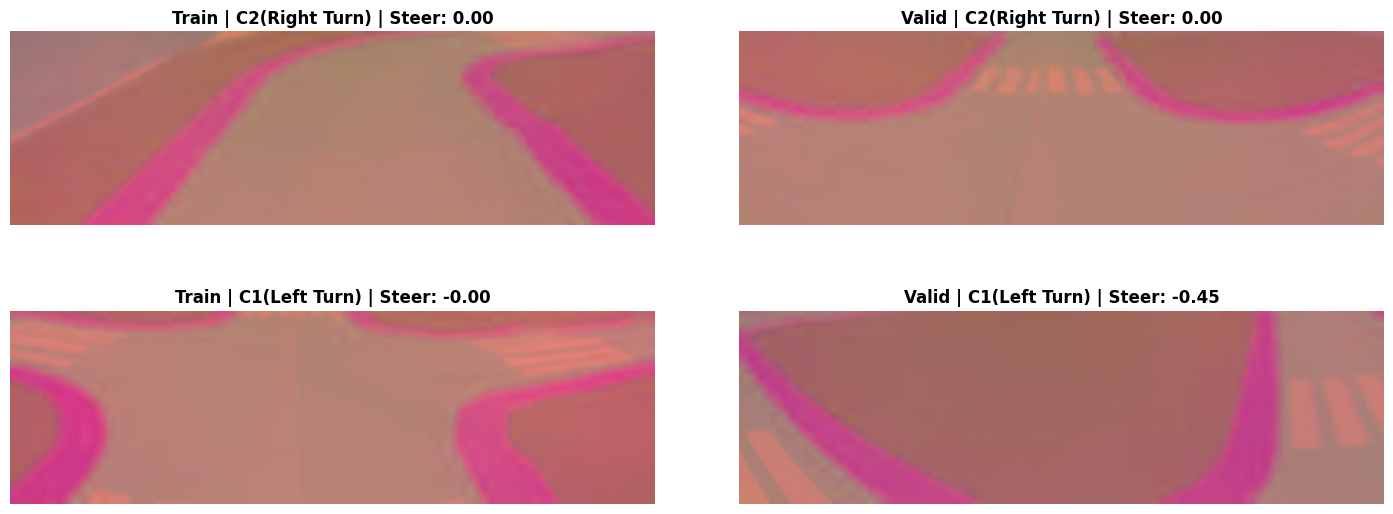

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt

nrow = 2
ncol = 2
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 6))
fig.tight_layout(pad=3.0)

# 커맨드 번호를 사람이 읽기 쉬운 텍스트로 매핑
cmd_dict = {0: 'C0(Outskirts)', 1: 'C1(Left Turn)', 2: 'C2(Right Turn)', 3: 'C3(Straight)'}

for i in range(nrow):
    # ==========================================
    # 1. 훈련(Training) 데이터 랜덤 추출
    # ==========================================
    rand_train = random.randint(0, len(X_train_img) - 1)

    # 💡 원핫 인코딩된 배열(예: [0,1,0,0])에서 다시 숫자 '1'을 찾아냅니다.
    train_cmd_num = np.argmax(X_train_cmd[rand_train])
    train_cmd_text = cmd_dict[train_cmd_num]

    # YUV 이미지 출력 (기괴한 색이 정상입니다!)
    axes[i][0].imshow(X_train_img[rand_train])
    # 💡 제목에 커맨드(Command) 정보를 추가로 띄워줍니다!
    axes[i][0].set_title(f"Train | {train_cmd_text} | Steer: {y_train[rand_train]:.2f}", fontweight='bold')
    axes[i][0].axis('off')

    # ==========================================
    # 2. 검증(Validation) 데이터 랜덤 추출
    # ==========================================
    rand_valid = random.randint(0, len(X_valid_img) - 1)

    valid_cmd_num = np.argmax(X_valid_cmd[rand_valid])
    valid_cmd_text = cmd_dict[valid_cmd_num]

    axes[i][1].imshow(X_valid_img[rand_valid])
    axes[i][1].set_title(f"Valid | {valid_cmd_text} | Steer: {y_valid[rand_valid]:.2f}", fontweight='bold')
    axes[i][1].axis('off')

plt.show()

In [13]:
import gc

print("🧹 램(RAM) 다이어트를 시작합니다...")

# 1. 8:2 분할이 끝났으므로, 거대한 원본 데이터들을 메모리에서 강제 삭제!
try:
    del X_images
    del X_commands_onehot
    del X_commands_raw
    del y_steering
    print("✅ 원본 데이터 삭제 성공!")
except NameError:
    print("✅ 이미 삭제되었습니다.")

# 2. 파이썬 가비지 컬렉터(Garbage Collector)를 깨워서 램 공간을 즉시 회수!
gc.collect()

print("🎉 램 청소 완료! 우측 상단의 RAM 사용량을 확인해 보세요.")

🧹 램(RAM) 다이어트를 시작합니다...
✅ 이미 삭제되었습니다.
🎉 램 청소 완료! 우측 상단의 RAM 사용량을 확인해 보세요.


11.모델 학습(5~10분가량 소요)

In [21]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('❌ GPU를 찾을 수 없습니다. [런타임 -> 런타임 유형 변경]에서 T4 GPU를 선택했는지 확인하세요!')
else:
  print('✅ GPU가 준비되었습니다:', device_name)

✅ GPU가 준비되었습니다: /device:GPU:0


2026-05-03 23:03:39.393239: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-03 23:03:39.393360: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-03 23:03:39.393377: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-03 23:03:39.393382: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-05-03 23:03:39.393559: I external/lo

In [14]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. 가중치 계산 삭제 (스마트 언더샘플링으로 이미 완벽함!)
# ==========================================
print("⚖️ 데이터는 이미 황금 밸런스로 언더샘플링 되었으므로 class_weight를 생략합니다.")

# ==========================================
# 2. 콜백(Callback) 3대장 설정
# ==========================================
model_output_dir = "/home/swjin/project/model"
os.makedirs(model_output_dir, exist_ok=True)

# 1) 베스트 모델 저장
checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(model_output_dir, 'cil_navigation_best_0505.h5'),
    monitor='val_loss',
    verbose=1,
    save_best_only=True
)

# 2) 조기 종료 (과적합 방지)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7, # 7번의 에포크 동안 val_loss 개선이 없으면 강제 종료
    verbose=1,
    restore_best_weights=True # 종료 시 가장 좋았던 가중치로 복구
)

# 3) 동적 학습률 감소 (미세 조정)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, # 개선이 없으면 학습률을 50%로 깎음
    patience=3, # 3번 참아보고 깎음
    min_lr=1e-6,
    verbose=1
)

print("\n🚀 다중 입력(CIL) 딥러닝 모델 학습을 시작합니다!")

# ==========================================
# 3. 모델 학습 (model.fit)
# ==========================================
history = model.fit(
    x=[X_train_img, X_train_cmd],                 
    y=y_train,
    validation_data=([X_valid_img, X_valid_cmd], y_valid), 
    batch_size=64,       # 다중 입력이므로 배치 사이즈를 64로 올려 VRAM 활용 극대화
    epochs=50,           # EarlyStopping을 믿고 넉넉하게 50 부여
    verbose=1,
    shuffle=True,
    callbacks=[checkpoint_callback, early_stop, reduce_lr] # 삼신기 장착
    # class_weight는 삭제합니다!
)

# ==========================================
# 4. 라즈베리 파이 최적화 TFLite 변환 (일반 & 양자화 2종 세트 추출)
# ==========================================
print("\n⚙️ 학습 완료! 두 가지 버전의 TFLite 모델 변환을 시작합니다...")

# 가장 성능이 좋았던 모델 로드
best_model = tf.keras.models.load_model(os.path.join(model_output_dir, 'cil_navigation_best_0505.h5'))

# ------------------------------------------
# 📦 버전 A: 일반 TFLite 모델 (양자화 X, 32비트 실수형)
# ------------------------------------------
print("⏳ 일반 TFLite 모델 변환 중...")
converter_normal = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model_normal = converter_normal.convert()

tflite_path_normal = os.path.join(model_output_dir, 'my_rc_car_cil_model_normal_0505.tflite')
with open(tflite_path_normal, "wb") as f:
    f.write(tflite_model_normal)
print(f"✅ 일반 모델 저장 완료: {tflite_path_normal}")

# ------------------------------------------
# ⚡ 버전 B: 양자화 TFLite 모델 (Edge AI 최적화)
# ------------------------------------------
print("\n⏳ 양자화(Quantized) TFLite 모델 변환 중...")
converter_quant = tf.lite.TFLiteConverter.from_keras_model(best_model)
# 💡 핵심 최적화 옵션 활성화
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT] 
tflite_model_quant = converter_quant.convert()

tflite_path_quant = os.path.join(model_output_dir, 'my_rc_car_cil_model_quantized_0505.tflite')
with open(tflite_path_quant, "wb") as f:
    f.write(tflite_model_quant)
print(f"✅ 양자화 모델 저장 완료: {tflite_path_quant}")

# ------------------------------------------
print("\n🎉 모든 과정이 완벽하게 끝났습니다!")
print("👉 이제 라즈베리파이에 두 파일을 모두 넣고, 추론 코드에서 모델 이름만 바꿔가며 직접 FPS(속도)와 주행 안정성을 비교해 보세요!")

⚖️ 데이터는 이미 황금 밸런스로 언더샘플링 되었으므로 class_weight를 생략합니다.

🚀 다중 입력(CIL) 딥러닝 모델 학습을 시작합니다!
Epoch 1/50


2026-05-05 23:54:08.457674: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inCIL_Modern_Edge/spatial_dropout2d/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-05 23:54:08.948832: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-05-05 23:54:09.082203: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-05 23:54:09.097528: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:225] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-05-05 23:54:09.097576: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:228] Used ptxas at /usr/local/cuda/bin/ptxas
2026-05-05 23:54:09.097917: W external/local_xla/xla/stream_executor/gpu/redzone_allocator.cc:322] UNIMPLEMENTED: /usr/local/cuda/bin/ptxas p

201/201 [==============================] - ETA: 0s - loss: 0.1881
Epoch 1: val_loss improved from inf to 0.05355, saving model to /home/swjin/project/model/cil_navigation_best_0505.h5


/home/swjin/miniconda3/envs/rc_car/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


201/201 [==============================] - 12s 27ms/step - loss: 0.1881 - val_loss: 0.0536 - lr: 1.0000e-04
Epoch 2/50
200/201 [============================>.] - ETA: 0s - loss: 0.0775
Epoch 2: val_loss improved from 0.05355 to 0.03073, saving model to /home/swjin/project/model/cil_navigation_best_0505.h5
201/201 [==============================] - 5s 25ms/step - loss: 0.0774 - val_loss: 0.0307 - lr: 1.0000e-04
Epoch 3/50
199/201 [============================>.] - ETA: 0s - loss: 0.0556
Epoch 3: val_loss improved from 0.03073 to 0.02519, saving model to /home/swjin/project/model/cil_navigation_best_0505.h5
201/201 [==============================] - 5s 25ms/step - loss: 0.0556 - val_loss: 0.0252 - lr: 1.0000e-04
Epoch 4/50
200/201 [============================>.] - ETA: 0s - loss: 0.0445
Epoch 4: val_loss improved from 0.02519 to 0.02249, saving model to /home/swjin/project/model/cil_navigation_best_0505.h5
201/201 [==============================] - 5s 25ms/step - loss: 0.0445 - val_loss

INFO:tensorflow:Assets written to: /tmp/tmpteoqfggf/assets
2026-05-05 23:58:03.300785: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-05 23:58:03.300836: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-05 23:58:03.302125: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpteoqfggf
2026-05-05 23:58:03.305451: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-05 23:58:03.305467: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpteoqfggf
2026-05-05 23:58:03.316197: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-05-05 23:58:03.319483: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-05 23:58:03.433512: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

✅ 일반 모델 저장 완료: /home/swjin/project/model/my_rc_car_cil_model_normal_0505.tflite

⏳ 양자화(Quantized) TFLite 모델 변환 중...
INFO:tensorflow:Assets written to: /tmp/tmp2lg_hxy5/assets


INFO:tensorflow:Assets written to: /tmp/tmp2lg_hxy5/assets


✅ 양자화 모델 저장 완료: /home/swjin/project/model/my_rc_car_cil_model_quantized_0505.tflite

🎉 모든 과정이 완벽하게 끝났습니다!
👉 이제 라즈베리파이에 두 파일을 모두 넣고, 추론 코드에서 모델 이름만 바꿔가며 직접 FPS(속도)와 주행 안정성을 비교해 보세요!


2026-05-05 23:58:05.811349: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-05 23:58:05.811393: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-05 23:58:05.811512: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp2lg_hxy5
2026-05-05 23:58:05.814692: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-05 23:58:05.814708: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp2lg_hxy5
2026-05-05 23:58:05.827589: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-05 23:58:05.937511: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp2lg_hxy5
2026-05-05 23:58:05.965522: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 154010 

12. 결과확인

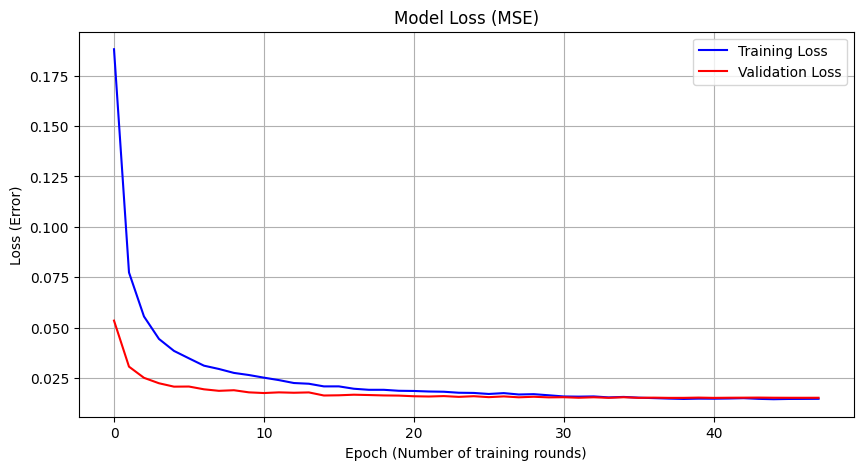

In [15]:
import matplotlib.pyplot as plt

# 메모리에 있는 history 객체에서 loss 데이터만 뽑아서 바로 그립니다!
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], color='blue', label='Training Loss')

# 💡 오타 수정 완료! (plt.辅plot -> plt.plot)
plt.plot(history.history['val_loss'], color='red', label='Validation Loss')

plt.title('Model Loss (MSE)')
plt.ylabel('Loss (Error)')
plt.xlabel('Epoch (Number of training rounds)')
plt.legend()
plt.grid(True)
plt.show()

13. 검증

In [16]:
print("현재 메모리에 살아있는 데이터셋 목록:")
for name in list(locals().keys()):
    if 'X_' in name or 'y_' in name:
        print(f"✅ {name}")

현재 메모리에 살아있는 데이터셋 목록:
✅ X_train_img
✅ X_valid_img
✅ X_train_cmd
✅ X_valid_cmd
✅ y_train
✅ y_valid
✅ my_imread
✅ early_stop


4/4 [==============================] - 0s 21ms/step
📊 검증 요약 (Sample: 100장)
   - MSE: 0.0256
   - R2 Score: 63.72%
----------------------------------------


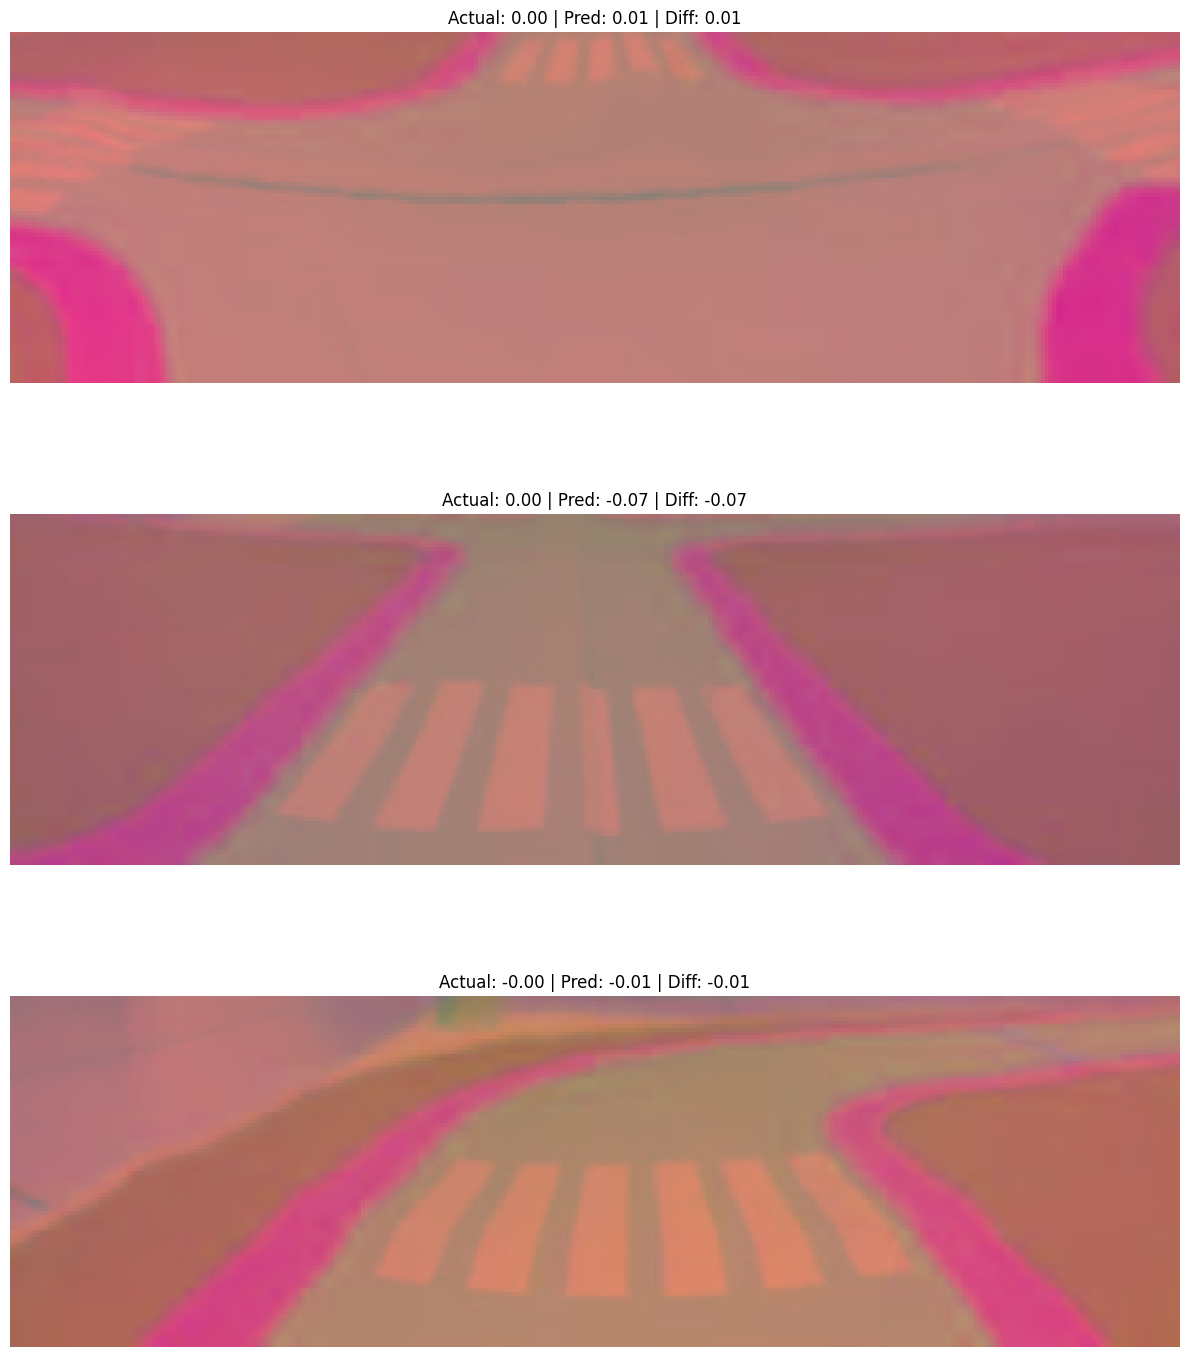

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 테스트용 랜덤 인덱스 뽑기 (살아있는 X_valid_img 기준)
n_tests = 100
# [수정] X_img_test 대신 실제 변수명인 X_valid_img 사용
indices = np.random.choice(len(X_valid_img), n_tests, replace=False) 

# 2. 데이터 추출
test_images = X_valid_img[indices]
test_cmds   = X_valid_cmd[indices]
test_labels = y_valid[indices]

# 3. 예측 실행 (이미 로드된 model 변수 사용)
# [참고] 모델이 [이미지, 커맨드] 입력을 받는 구조라면 아래와 같이 리스트로 넣어줍니다.
y_pred = model.predict([test_images, test_cmds])

# 4. 결과 요약 및 시각화
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(test_labels, y_pred)
r2 = r2_score(test_labels, y_pred)

print(f"📊 검증 요약 (Sample: {n_tests}장)")
print(f"   - MSE: {mse:.4f}")
print(f"   - R2 Score: {r2:.2%}")
print("-" * 40)

# 5. 시각화 (상위 3장)
n_show = 3
plt.figure(figsize=(12, 5 * n_show))
for i in range(n_show):
    plt.subplot(n_show, 1, i+1)
    plt.imshow(test_images[i]) # 정규화된 float32 데이터라 바로 출력 가능
    
    actual = test_labels[i]
    pred = y_pred[i][0]
    
    plt.title(f"Actual: {actual:.2f} | Pred: {pred:.2f} | Diff: {pred-actual:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

🖼️ 선택된 파일: video_12574_C0_L+030_R+050.jpg
🚦 동일 이미지에 대한 커맨드(C0~C3) 주입 테스트 시작
--------------------------------------------------
🔹 직진(C0) 명령 주입 시 -> 예측 조향각: 0.0271
🔹 좌회전(C1) 명령 주입 시 -> 예측 조향각: -0.0491
🔹 우회전(C2) 명령 주입 시 -> 예측 조향각: 0.0771
🔹 정지(C3) 명령 주입 시 -> 예측 조향각: 0.0272
--------------------------------------------------


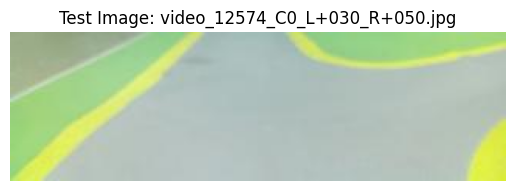

In [39]:
import cv2
import numpy as np
import os

# 1. 테스트하고 싶은 파일 이름만 딱 적으세요 (탐색기에서 보고 고르기)
target_file = 'video_12574_C0_L+030_R+050.jpg' # 예시 파일명
file_path = os.path.join('/home/swjin/project/video', target_file)

# 2. 이미지 로드 및 학습 때와 동일한 전처리 (매우 중요!)
img_bgr = cv2.imread(file_path)
if img_bgr is None:
    print("❌ 파일을 찾을 수 없습니다. 경로와 파일명을 확인하세요!")
else:
    # BGR -> RGB -> YUV 변환
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_yuv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YUV)
    
    # 정규화 및 배치 차원 추가 (1, 96, 320, 3)
    test_img = np.float32(img_yuv) / 255.0
    test_img = np.expand_dims(test_img, axis=0)

    print(f"🖼️ 선택된 파일: {target_file}")
    print("🚦 동일 이미지에 대한 커맨드(C0~C3) 주입 테스트 시작")
    print("-" * 50)

    # 3. 4가지 커맨드를 각각 넣었을 때 모델의 반응 확인
    for c_val in range(4):
        # 커맨드 원핫 인코딩 (1, 4)
        mock_cmd = np.zeros((1, 4))
        mock_cmd[0, c_val] = 1.0
        
        # 모델 예측
        pred = model.predict([test_img, mock_cmd], verbose=0)
        
        # 결과 출력
        cmd_name = {0: "직진(C0)", 1: "좌회전(C1)", 2: "우회전(C2)", 3: "정지(C3)"}
        print(f"🔹 {cmd_name[c_val]} 명령 주입 시 -> 예측 조향각: {pred[0][0]:.4f}")

    print("-" * 50)
    
    # 4. 이미지 확인 (색상은 BGR->RGB로 다시 돌려서 출력)
    import matplotlib.pyplot as plt
    plt.imshow(img_rgb)
    plt.title(f"Test Image: {target_file}")
    plt.axis('off')
    plt.show()

In [16]:
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, r2_score

# [수정 1] 모델 로드는 함수 밖에서 딱 한 번만! (메모리 절약)
print("📦 모델 로딩 중...")
model_path = f'{model_output_dir}/cil_navigation_best.h5'
model = tf.keras.models.load_model(model_path, custom_objects={'mse': tf.keras.losses.MeanSquaredError()})

def summarize_prediction(Y_true, Y_pred):
    mse = mean_squared_error(Y_true, Y_pred)
    r_squared = r2_score(Y_true, Y_pred)
    print(f'✅ 검증 결과 요약')
    print(f'   - MSE (오차): {mse:.4f}')
    print(f'   - R-Squared (결정계수): {r_squared:.2%}')
    print("-" * 30)

# [수정 2] 멀티 입력(이미지+커맨드)을 지원하도록 수정
def validate_model(img_data, cmd_data, label_data):
    # 모델 예측 (이미지와 커맨드를 리스트로 묶어서 전달)
    y_pred = model.predict([img_data, cmd_data])
    summarize_prediction(label_data, y_pred)
    return y_pred

# [수정 3] 테스트 데이터 추출 (랜덤 100장)
n_tests = 100
indices = np.random.choice(len(X_img_test), n_tests, replace=False)
test_images = X_img_test[indices]
test_cmds = X_cmd_test[indices]
test_labels = y_test[indices]

# 예측 실행
y_pred = validate_model(test_images, test_cmds, test_labels)

# [수정 4] 시각화 개선 (실제 조향각 vs 예측 조향각 비교)
n_show = 3
plt.figure(figsize=(12, 4 * n_show))

for i in range(n_show):
    plt.subplot(n_show, 1, i+1)
    # BGR -> RGB 변환 (OpenCV 사용 시 필수)
    plt.imshow(test_images[i]) 
    
    actual = test_labels[i]
    predict = y_pred[i][0]
    diff = predict - actual
    
    title_str = f"Actual: {actual:.2f} | Pred: {predict:.2f} | Diff: {diff:.2f}"
    plt.title(title_str, color='red' if abs(diff) > 0.2 else 'green')
    plt.axis('off')

plt.tight_layout()
plt.show()

📦 모델 로딩 중...


NameError: name 'X_img_test' is not defined

14.video 폴더 삭제 (video 폴더 삭제후 [3.압축풀기] 부터 다시 진행하여 학습)

In [ ]:
import shutil

shutil.rmtree("/content/video")